# Détection d’anomalies par autoencodeurs sur données eBPF

**Objectif** : entraîner et comparer un autoencodeur dense (baseline) et un *Denoising Autoencoder* (DAE) dans un cadre *one-class* (données supposées normales), puis produire des figures et artefacts reproductibles.

**Exécution** : ce notebook est conçu pour être exécuté *de haut en bas* sans modification.


## Sommaire
1. Configuration et reproductibilité  
2. Chargement des données  
3. Prétraitement (pipeline partagé)  
4. Split train/val/test + normalisation  
5. DataLoader  
6. Fonctions utilitaires (scores, visualisations, sauvegarde)  
7. Modèle 1 — Autoencodeur dense (AE)  
8. Modèle 2 — Denoising Autoencoder (DAE)  
9. Modèle 3 — Sparse Autoencoder (SAE)  
10. Comparaison & synthèse  


## 1) Configuration et reproductibilité

In [1]:
# Paramètres principaux (gardés identiques aux choix d'ingénierie initiaux)

SEED = 42

# Split (train/val/test)
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# Entraînement
MAX_EPOCHS = 200
PATIENCE  = 12
LR        = 1e-3
WEIGHT_DECAY = 1e-5
BATCH_SIZE = 128

# Architecture
LATENT_DIM = 8
DROPOUT    = 0.1

# Seuil d'anomalie (quantile sur la validation)
THRESH_Q = 0.995


In [2]:
import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import joblib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Reproductibilité ---
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)
print("Torch:", torch.__version__)


DEVICE: cpu
Torch: 2.8.0+cu128


## 2) Chargement des données

In [3]:
# Chemin du dataset (adapter si nécessaire)
CSV_PATH = "dataset_autoencoder_all.csv"

df = pd.read_csv(CSV_PATH)
print("Shape:", df.shape)
print("Columns:", len(df.columns))
df.head(3)


Shape: (13641, 37)
Columns: 37


,window_start,cpu_events,cpu_time_sum,cpu_time_mean,cpu_time_max,cpu_unique_pids,cpu_unique_comms,cpu_entropy_comm,exec_count,exec_unique_binaries,...,net_unique_dst_port,net_entropy_dst_ports,net_unknown_dst_ip_count,net_suspicious_ports_flag,priv_event_count,priv_uid0_count,priv_tmp_mod_count,priv_script_mod_count,priv_suspicious_permission_flag,priv_entropy_filename
0,2025-12-17 19:30:31,2583.0,1.503359e+09,582020.684088,113472869.0,90.0,56.0,4.338710,5.0,5.0,...,2.0,2.108423e-01,58.0,0.0,1.0,0.0,0.0,0.0,0.0,-0.0
1,2025-12-17 19:30:32,3713.0,2.351023e+09,633186.846216,99167129.0,153.0,65.0,4.387880,0.0,0.0,...,1.0,-1.442823e-12,22.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2025-12-17 19:30:33,2531.0,2.024926e+09,800049.721454,42237942.0,119.0,48.0,4.302813,0.0,0.0,...,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3) Prétraitement commun (pipeline partagé)
Cette section prépare les variables, applique les transformations (`clip` entropies + `log1p` sur certaines métriques), puis réalise le split train/val/test et la normalisation (fit sur train).

In [4]:
# 3.1) Temps (conservé pour traçage uniquement)
df["window_start"] = pd.to_datetime(df["window_start"], errors="coerce")

# 3.2) Colonnes de features (tout sauf window_start)
feature_cols = [c for c in df.columns if c != "window_start"]

X_raw = df[feature_cols].copy()
X_raw = X_raw.replace([np.inf, -np.inf], np.nan).fillna(0.0)

# 3.3) Définir catégories de colonnes (heuristiques simples et reproductibles)
entropy_cols = [c for c in feature_cols if "entropy" in c.lower()]

# Colonnes à log-transformer (aligné sur l'ancien notebook)
log_candidates = []
for c in feature_cols:
    cl = c.lower()
    if c == "proc_churn":
        continue
    if any(k in cl for k in ["count", "sum", "max", "bytes", "events"]):
        log_candidates.append(c)

# Sécurité : log1p seulement si min >= 0 (évite les surprises si une colonne contient des valeurs négatives)
log_cols = [c for c in log_candidates if X_raw[c].min() >= 0.0]
nonlog_due_to_negative = [c for c in log_candidates if X_raw[c].min() < 0.0]

print("Nb features:", len(feature_cols))
print("Nb entropy_cols:", len(entropy_cols))
print("Nb log_cols:", len(log_cols))
if nonlog_due_to_negative:
    print("Skipped log1p (valeurs négatives détectées):", nonlog_due_to_negative)


Nb features: 36
Nb entropy_cols: 5
Nb log_cols: 19


In [5]:
# 3.4) Règles de prétraitement
X = X_raw.copy()

# a) Clipping des entropies (entropies >= 0)
for c in entropy_cols:
    X[c] = X[c].clip(lower=0.0)

# b) log1p sur les variables fortement asymétriques
for c in log_cols:
    X[c] = np.log1p(X[c].astype(np.float64))

# c) Safety NaN/inf
X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)

X.head(3)


,cpu_events,cpu_time_sum,cpu_time_mean,cpu_time_max,cpu_unique_pids,cpu_unique_comms,cpu_entropy_comm,exec_count,exec_unique_binaries,exec_tmp_count,...,net_unique_dst_port,net_entropy_dst_ports,net_unknown_dst_ip_count,net_suspicious_ports_flag,priv_event_count,priv_uid0_count,priv_tmp_mod_count,priv_script_mod_count,priv_suspicious_permission_flag,priv_entropy_filename
0,7.857094,21.130968,582020.684088,18.547074,90.0,56.0,4.338710,1.791759,5.0,0.0,...,2.0,0.210842,4.077537,0.0,0.693147,0.0,0.0,0.0,0.0,-0.0
1,8.219865,21.578116,633186.846216,18.412317,153.0,65.0,4.387880,0.000000,0.0,0.0,...,1.0,0.000000,3.135494,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
2,7.836765,21.428799,800049.721454,17.558829,119.0,48.0,4.302813,0.000000,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0


## 4) Split train/val/test + scaling

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_tmp = train_test_split(X, test_size=0.30, random_state=SEED, shuffle=True)
X_val, X_test = train_test_split(X_tmp, test_size=0.50, random_state=SEED, shuffle=True)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

in_dim = X_train_s.shape[1]
print("in_dim:", in_dim)


Train: (9548, 36) Val: (2046, 36) Test: (2047, 36)
in_dim: 36


## 5) Dataset/DataLoader

In [7]:
NUM_WORKERS = 0

train_loader = DataLoader(TensorDataset(torch.from_numpy(X_train_s)), batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=(DEVICE=="cuda"))
val_loader   = DataLoader(TensorDataset(torch.from_numpy(X_val_s)),   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(DEVICE=="cuda"))
test_loader  = DataLoader(TensorDataset(torch.from_numpy(X_test_s)),  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(DEVICE=="cuda"))

print("Batches train/val/test:", len(train_loader), len(val_loader), len(test_loader))


Batches train/val/test: 75 16 16


## 6) Fonctions communes

In [8]:
@torch.no_grad()
def reconstruction_errors(model, loader):
    model.eval()
    errs = []
    for (xb,) in loader:
        xb = xb.to(DEVICE)
        x_hat = model(xb)
        e = torch.mean((x_hat - xb) ** 2, dim=1)
        errs.append(e.detach().cpu().numpy())
    return np.concatenate(errs, axis=0)

@torch.no_grad()
def reconstruction_errors_array(model, Xs: np.ndarray, batch_size: int = 512):
    model.eval()
    errs = []
    for i in range(0, Xs.shape[0], batch_size):
        xb = torch.from_numpy(Xs[i:i+batch_size]).to(DEVICE)
        x_hat = model(xb)
        e = torch.mean((x_hat - xb) ** 2, dim=1)
        errs.append(e.detach().cpu().numpy())
    return np.concatenate(errs, axis=0)

def make_df_vis(df, recon_err, threshold):
    df_vis = df[["window_start"]].copy()
    df_vis["recon_error"] = recon_err
    df_vis["is_anomaly"] = (df_vis["recon_error"] > threshold).astype(int)
    df_vis = df_vis.sort_values("window_start").reset_index(drop=True)
    df_vis["win_idx"] = np.arange(len(df_vis))
    return df_vis

def plot_hist(val_err, test_err, threshold, title):
    plt.figure()
    plt.hist(val_err, bins=60, alpha=0.6, label="Validation")
    plt.hist(test_err, bins=60, alpha=0.6, label="Test")
    plt.axvline(threshold, linewidth=2, label=f"Seuil q99.5 = {threshold:.3f}")
    plt.xlabel("Erreur de reconstruction (MSE par fenêtre)")
    plt.ylabel("Nombre de fenêtres")
    plt.title(title)
    plt.legend()
    plt.show()

def plot_time_index(df_vis, threshold, title):
    anom = df_vis[df_vis["is_anomaly"] == 1]
    plt.figure()
    plt.plot(df_vis["win_idx"], df_vis["recon_error"], linewidth=1, label="Erreur")
    plt.axhline(threshold, linewidth=2, label="Seuil")
    if len(anom) > 0:
        plt.scatter(anom["win_idx"], anom["recon_error"], s=20, label=f"Anomalies ({len(anom)})")
    plt.xlabel("Index de fenêtre (ordre temporel)")
    plt.ylabel("Erreur de reconstruction")
    plt.title(title)
    plt.legend()
    plt.show()
    return anom

def plot_rate_per_hour(df_vis, title):
    df_rate = df_vis.dropna(subset=["window_start"]).copy().set_index("window_start")
    rate_h = df_rate["is_anomaly"].resample("1h").mean()
    plt.figure()
    plt.plot(rate_h.index, rate_h.values, linewidth=1)
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4, maxticks=8))
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    plt.xlabel("Temps")
    plt.ylabel("Taux d'anomalies (moyenne horaire)")
    plt.title(title)
    plt.tight_layout()
    plt.show()


## 7) Modèle 1 — Autoencodeur dense (Baseline)

In [9]:
# --- Architectures AE / DAE / SAE (héritage) ---

def add_gaussian_noise(x: torch.Tensor, std: float) -> torch.Tensor:
    """Ajoute un bruit gaussien N(0, std^2) (utilisé par le DAE)."""
    if std <= 0:
        return x
    return x + torch.randn_like(x) * std


class MLP_AE(nn.Module):
    """Autoencodeur dense de base (baseline)."""

    def __init__(self, in_dim: int, latent_dim: int = 8, dropout: float = 0.1):
        super().__init__()
        self.in_dim = in_dim
        self.latent_dim = latent_dim
        self.dropout = dropout

        # Encoder / decoder identiques à la version initiale (choix d'ingénierie conservés)
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, 24),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(24, 16),
            nn.ReLU(),
            nn.Linear(16, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, 24),
            nn.ReLU(),
            nn.Linear(24, in_dim),
        )

    # --- Points d'extension (pour éviter la duplication AE/DAE/SAE) ---
    def preprocess(self, x: torch.Tensor, train: bool) -> torch.Tensor:
        """Pré-traitement éventuel de l'entrée (DAE ajoute du bruit en entraînement)."""
        return x

    def extra_loss(self, z: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        """Terme de pénalité éventuel (SAE ajoute une pénalité de parcimonie)."""
        return torch.zeros((), device=x.device)

    # --- API commune ---
    def encode(self, x: torch.Tensor) -> torch.Tensor:
        return self.encoder(x)

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        return self.decoder(z)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.encode(x)
        return self.decode(z)


class MLP_DAE(MLP_AE):
    """Denoising Autoencoder : même architecture que AE, mais entrée bruitée (train)."""

    def __init__(self, in_dim: int, latent_dim: int = 8, dropout: float = 0.1, noise_std: float = 0.05):
        super().__init__(in_dim=in_dim, latent_dim=latent_dim, dropout=dropout)
        self.noise_std = noise_std

    def preprocess(self, x: torch.Tensor, train: bool) -> torch.Tensor:
        return add_gaussian_noise(x, self.noise_std) if train else x


class MLP_SAE(MLP_AE):
    """Sparse Autoencoder : même architecture que AE, + pénalité L1 sur le latent."""

    def __init__(self, in_dim: int, latent_dim: int = 8, dropout: float = 0.1, l1_lambda: float = 1e-3):
        super().__init__(in_dim=in_dim, latent_dim=latent_dim, dropout=dropout)
        self.l1_lambda = l1_lambda

    def extra_loss(self, z: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        # pénalité L1 moyenne sur le latent (choix simple + stable numériquement)
        return self.l1_lambda * torch.mean(torch.abs(z))


### 7.1 Entraînement (baseline) + early stopping

In [10]:
def run_epoch(model, loader, optimizer, criterion, train: bool):
    """Boucle 1 epoch (train ou val) commune à AE/DAE/SAE.

    Retourne : (loss_total, loss_recon, loss_extra) moyens.
    """
    model.train(train)
    total_loss = 0.0
    total_recon = 0.0
    total_extra = 0.0
    n = 0

    for (xb,) in loader:
        xb = xb.to(DEVICE)
        if train:
            optimizer.zero_grad(set_to_none=True)

        xb_in = model.preprocess(xb, train=train)
        z = model.encode(xb_in)
        x_hat = model.decode(z)

        recon = criterion(x_hat, xb)
        extra = model.extra_loss(z, xb)
        loss = recon + extra

        if train:
            loss.backward()
            optimizer.step()

        bs = xb.size(0)
        total_loss += loss.item() * bs
        total_recon += recon.item() * bs
        total_extra += float(extra.detach().item()) * bs
        n += bs

    n = max(n, 1)
    return total_loss / n, total_recon / n, total_extra / n


# --- Entraînement baseline (AE) ---
in_dim = X_train_s.shape[1]
model_ae = MLP_AE(in_dim=in_dim, latent_dim=LATENT_DIM, dropout=DROPOUT).to(DEVICE)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_ae.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

best_val = float("inf")
best_state = None
pat = 0

for epoch in range(1, MAX_EPOCHS + 1):
    tr_total, tr_recon, tr_extra = run_epoch(model_ae, train_loader, optimizer, criterion, train=True)
    va_total, va_recon, va_extra = run_epoch(model_ae, val_loader,   optimizer, criterion, train=False)

    if va_total < best_val - 1e-6:
        best_val = va_total
        best_state = {k: v.detach().cpu().clone() for k, v in model_ae.state_dict().items()}
        pat = 0
    else:
        pat += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f"[AE] Epoch {epoch:03d} | train={tr_total:.6f} | val={va_total:.6f} | best_val={best_val:.6f}")

    if pat >= PATIENCE:
        print("[AE] Early stopping.")
        break

model_ae.load_state_dict(best_state)
model_ae.eval()


[AE] Epoch 001 | train=0.944165 | val=0.957919 | best_val=0.957919
[AE] Epoch 010 | train=0.416043 | val=0.533818 | best_val=0.533818
[AE] Epoch 020 | train=0.340407 | val=0.440882 | best_val=0.440882
[AE] Epoch 030 | train=0.318984 | val=0.398134 | best_val=0.398134
[AE] Epoch 040 | train=0.298447 | val=0.358343 | best_val=0.358343
[AE] Epoch 050 | train=0.275728 | val=0.315165 | best_val=0.315165
[AE] Epoch 060 | train=0.262426 | val=0.273517 | best_val=0.273517
[AE] Epoch 070 | train=0.240883 | val=0.250872 | best_val=0.248641
[AE] Epoch 080 | train=0.239498 | val=0.230588 | best_val=0.230588
[AE] Epoch 090 | train=0.234799 | val=0.217801 | best_val=0.216446
[AE] Epoch 100 | train=0.222675 | val=0.212090 | best_val=0.212090
[AE] Epoch 110 | train=0.221439 | val=0.216222 | best_val=0.205735
[AE] Epoch 120 | train=0.253065 | val=0.205490 | best_val=0.198820
[AE] Epoch 130 | train=0.206331 | val=0.205632 | best_val=0.198679
[AE] Epoch 140 | train=0.222774 | val=0.202687 | best_val=0.19

MLP_AE(
  (encoder): Sequential(
    (0): Linear(in_features=36, out_features=24, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=24, out_features=16, bias=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=8, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=16, out_features=24, bias=True)
    (4): ReLU()
    (5): Linear(in_features=24, out_features=36, bias=True)
  )
)

### 7.2 Score + seuil (baseline)

In [11]:
val_err_ae  = reconstruction_errors(model_ae, val_loader)
test_err_ae = reconstruction_errors(model_ae, test_loader)

threshold_ae = float(np.quantile(val_err_ae, THRESH_Q))

print("AE threshold:", threshold_ae)
print("AE Val mean/std:", val_err_ae.mean(), val_err_ae.std())
print("AE Test mean/std:", test_err_ae.mean(), test_err_ae.std())
print("AE Test anomaly rate:", (test_err_ae > threshold_ae).mean())


AE threshold: 4.389127254486084
AE Val mean/std: 0.19867866 0.9140671
AE Test mean/std: 0.14787439 0.4936122
AE Test anomaly rate: 0.0029311187103077674


### 7.3 Sauvegarde baseline

In [12]:
ART_AE = "artifacts_ae"
os.makedirs(ART_AE, exist_ok=True)

torch.save(model_ae.state_dict(), f"{ART_AE}/mlp_ae_lat8.pt")
joblib.dump(scaler, f"{ART_AE}/scaler.joblib")

meta_ae = {
    "model_type": "AE",
    "feature_cols": feature_cols,
    "entropy_cols": entropy_cols,
    "log_cols": log_cols,
    "latent_dim": 8,
    "dropout": 0.1,
    "threshold_value": threshold_ae,
    "threshold_quantile": 0.995,
    "seed": SEED,
}
joblib.dump(meta_ae, f"{ART_AE}/meta.joblib")

print("Saved:", ART_AE)


Saved: artifacts_ae


### 7.4 Visualisations baseline

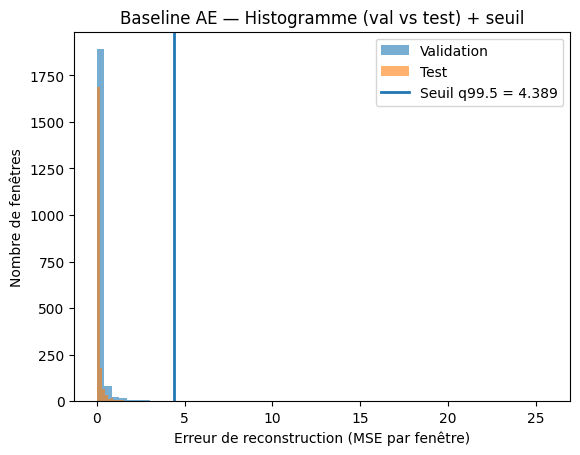

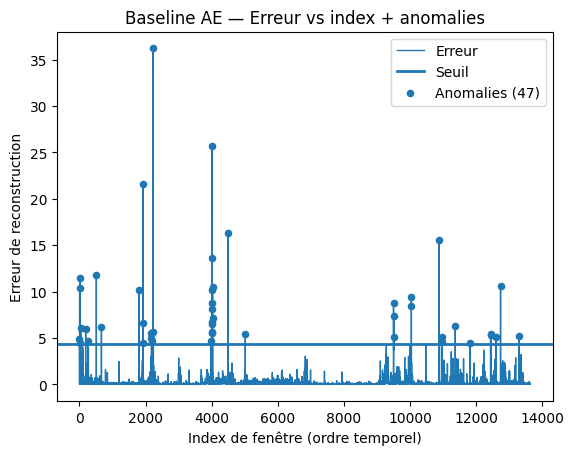

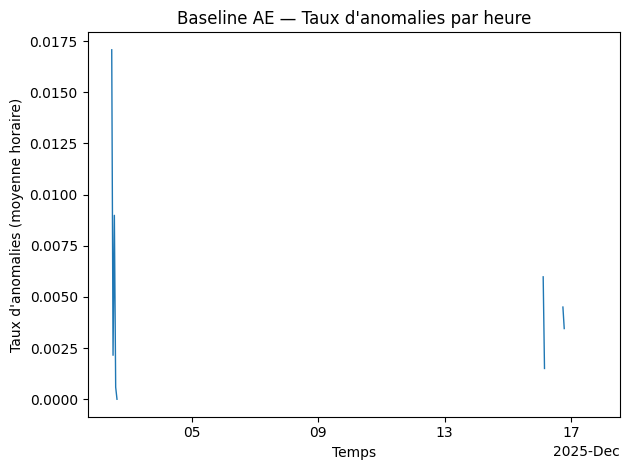

Nb anomalies AE (tout dataset): 47


In [13]:
all_err_ae = reconstruction_errors_array(model_ae, scaler.transform(X).astype(np.float32))
df_vis_ae = make_df_vis(df, all_err_ae, threshold_ae)

plot_hist(val_err_ae, test_err_ae, threshold_ae, title="Baseline AE — Histogramme (val vs test) + seuil")
_ = plot_time_index(df_vis_ae, threshold_ae, title="Baseline AE — Erreur vs index + anomalies")
plot_rate_per_hour(df_vis_ae, title="Baseline AE — Taux d'anomalies par heure")

print("Nb anomalies AE (tout dataset):", int(df_vis_ae["is_anomaly"].sum()))


## 8) Modèle 2 — Denoising Autoencoder (DAE)

In [14]:
# Le DAE hérite de MLP_AE et surcharge uniquement preprocess() (bruit en train).
# Ici on fixe l'écart-type du bruit (conservé comme dans la version initiale).

### 8.1 Entraînement DAE

In [15]:
NOISE_STD = 0.05

model_dae = MLP_DAE(in_dim=in_dim, latent_dim=LATENT_DIM, dropout=DROPOUT, noise_std=NOISE_STD).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_dae.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

best_val = float("inf")
best_state = None
pat = 0

for epoch in range(1, MAX_EPOCHS + 1):
    tr_total, _, _ = run_epoch(model_dae, train_loader, optimizer, criterion, train=True)
    va_total, _, _ = run_epoch(model_dae, val_loader,   optimizer, criterion, train=False)

    if va_total < best_val - 1e-6:
        best_val = va_total
        best_state = {k: v.detach().cpu().clone() for k, v in model_dae.state_dict().items()}
        pat = 0
    else:
        pat += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f"[DAE] Epoch {epoch:03d} | train={tr_total:.6f} | val={va_total:.6f} | best_val={best_val:.6f}")

    if pat >= PATIENCE:
        print("[DAE] Early stopping.")
        break

model_dae.load_state_dict(best_state)
model_dae.eval()


[DAE] Epoch 001 | train=0.975979 | val=1.018327 | best_val=1.018327
[DAE] Epoch 010 | train=0.432158 | val=0.542483 | best_val=0.542483
[DAE] Epoch 020 | train=0.357703 | val=0.474193 | best_val=0.474193
[DAE] Epoch 030 | train=0.319791 | val=0.414698 | best_val=0.414698
[DAE] Epoch 040 | train=0.288818 | val=0.374677 | best_val=0.374677
[DAE] Epoch 050 | train=0.268347 | val=0.338489 | best_val=0.338489
[DAE] Epoch 060 | train=0.264873 | val=0.297934 | best_val=0.297934
[DAE] Epoch 070 | train=0.246409 | val=0.262925 | best_val=0.262925
[DAE] Epoch 080 | train=0.242706 | val=0.238514 | best_val=0.238514
[DAE] Epoch 090 | train=0.233276 | val=0.231505 | best_val=0.223411
[DAE] Epoch 100 | train=0.231720 | val=0.205535 | best_val=0.198462
[DAE] Epoch 110 | train=0.223034 | val=0.199765 | best_val=0.190003
[DAE] Epoch 120 | train=0.206713 | val=0.189259 | best_val=0.189259
[DAE] Epoch 130 | train=0.218462 | val=0.189079 | best_val=0.187305
[DAE] Epoch 140 | train=0.215961 | val=0.197035 

MLP_DAE(
  (encoder): Sequential(
    (0): Linear(in_features=36, out_features=24, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=24, out_features=16, bias=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=8, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=16, out_features=24, bias=True)
    (4): ReLU()
    (5): Linear(in_features=24, out_features=36, bias=True)
  )
)

### 8.2 Score + seuil (DAE)

In [16]:
val_err_dae  = reconstruction_errors(model_dae, val_loader)
test_err_dae = reconstruction_errors(model_dae, test_loader)

threshold_dae = float(np.quantile(val_err_dae, THRESH_Q))

print("DAE threshold:", threshold_dae)
print("DAE Val mean/std:", val_err_dae.mean(), val_err_dae.std())
print("DAE Test mean/std:", test_err_dae.mean(), test_err_dae.std())
print("DAE Test anomaly rate:", (test_err_dae > threshold_dae).mean())


DAE threshold: 4.146695613861084
DAE Val mean/std: 0.18378484 0.80579823
DAE Test mean/std: 0.14336792 0.48181373
DAE Test anomaly rate: 0.002442598925256473


### 8.3 Sauvegarde DAE

In [17]:
ART_DAE = "artifacts_dae"
os.makedirs(ART_DAE, exist_ok=True)

torch.save(model_dae.state_dict(), f"{ART_DAE}/mlp_dae_lat8.pt")

meta_dae = {
    "model_type": "DAE",
    "latent_dim": 8,
    "dropout": 0.1,
    "noise_std": float(NOISE_STD),
    "threshold_value": threshold_dae,
    "threshold_quantile": 0.995,
    "seed": SEED,
    "note": "Même pipeline/scaler/colonnes que baseline",
}
joblib.dump(meta_dae, f"{ART_DAE}/meta_dae.joblib")

print("Saved:", ART_DAE)


Saved: artifacts_dae


### 8.4 Visualisations DAE

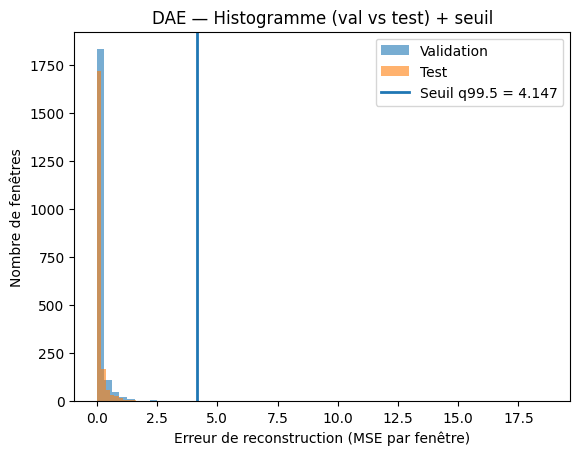

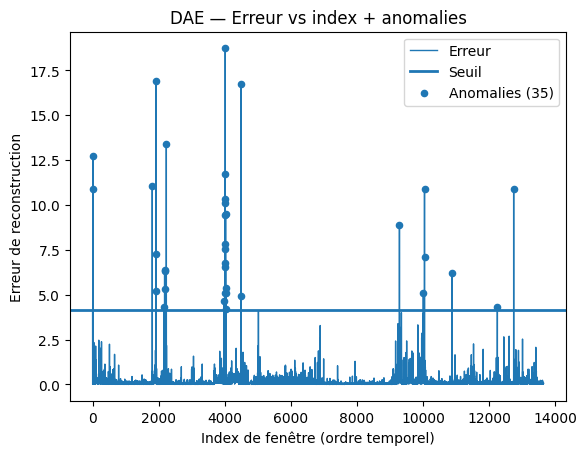

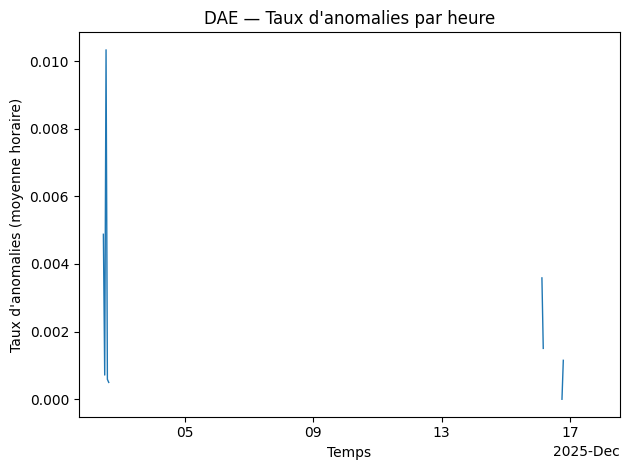

Nb anomalies DAE (tout dataset): 35


In [18]:
all_err_dae = reconstruction_errors_array(model_dae, scaler.transform(X).astype(np.float32))
df_vis_dae = make_df_vis(df, all_err_dae, threshold_dae)

plot_hist(val_err_dae, test_err_dae, threshold_dae, title="DAE — Histogramme (val vs test) + seuil")
_ = plot_time_index(df_vis_dae, threshold_dae, title="DAE — Erreur vs index + anomalies")
plot_rate_per_hour(df_vis_dae, title="DAE — Taux d'anomalies par heure")

print("Nb anomalies DAE (tout dataset):", int(df_vis_dae["is_anomaly"].sum()))


## 9) Modèle 3 — Sparse Autoencoder (SAE)

Même pipeline de données que pour AE/DAE, avec une pénalisation L1 sur l'espace latent pour encourager la parcimonie.

### 9.1 Architecture

In [19]:
# Le SAE hérite de MLP_AE et surcharge uniquement extra_loss() (pénalité L1 sur le latent).
# L'architecture (couches) reste identique au baseline.

### 9.2 Fonction de coût (MSE + λ·L1(latent))

In [20]:
# NOTE : La pénalité de parcimonie est intégrée via model.extra_loss(z, x).
# Le critère de reconstruction reste MSE (criterion = nn.MSELoss()).

### 9.3 Boucle d'entraînement/validation (epoch)

In [21]:
# NOTE : On réutilise run_epoch() (fonction commune) pour le SAE,
# qui retourne aussi (recon, extra) pour afficher la décomposition de la perte.

### 9.4 Entraînement + early stopping

In [22]:
# Hyperparams (conservés)
max_epochs = 200
patience = 12
l1_lambda = 1e-3  # sparsity strength

model_sae = MLP_SAE(in_dim=in_dim, latent_dim=LATENT_DIM, dropout=DROPOUT, l1_lambda=l1_lambda).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_sae.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

best_val = float("inf")
best_state = None
pat = 0

for epoch in range(1, max_epochs + 1):
    tr_total, tr_recon, tr_sparse = run_epoch(model_sae, train_loader, optimizer, criterion, train=True)
    va_total, va_recon, va_sparse = run_epoch(model_sae, val_loader,   optimizer, criterion, train=False)

    if va_total < best_val - 1e-6:
        best_val = va_total
        best_state = {k: v.detach().cpu().clone() for k, v in model_sae.state_dict().items()}
        pat = 0
    else:
        pat += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f"[SAE] Epoch {epoch:03d} | "
              f"train={tr_total:.6f} (recon={tr_recon:.6f}, sparse={tr_sparse:.6f}) | "
              f"val={va_total:.6f} (recon={va_recon:.6f}, sparse={va_sparse:.6f}) | "
              f"best_val={best_val:.6f}")

    if pat >= patience:
        print("[SAE] Early stopping.")
        break

model_sae.load_state_dict(best_state)
model_sae.eval()


[SAE] Epoch 001 | train=0.945291 (recon=0.945018, sparse=0.000273) | val=0.943802 (recon=0.943045, sparse=0.000757) | best_val=0.943802
[SAE] Epoch 010 | train=0.424058 (recon=0.422955, sparse=0.001103) | val=0.545916 (recon=0.544785, sparse=0.001131) | best_val=0.545916
[SAE] Epoch 020 | train=0.354047 (recon=0.352929, sparse=0.001118) | val=0.473373 (recon=0.472223, sparse=0.001149) | best_val=0.473373
[SAE] Epoch 030 | train=0.333429 (recon=0.332371, sparse=0.001058) | val=0.434612 (recon=0.433514, sparse=0.001099) | best_val=0.434612
[SAE] Epoch 040 | train=0.309333 (recon=0.308291, sparse=0.001041) | val=0.401846 (recon=0.400785, sparse=0.001062) | best_val=0.401846
[SAE] Epoch 050 | train=0.287732 (recon=0.286673, sparse=0.001059) | val=0.359416 (recon=0.358320, sparse=0.001096) | best_val=0.359416
[SAE] Epoch 060 | train=0.271529 (recon=0.270458, sparse=0.001071) | val=0.329693 (recon=0.328593, sparse=0.001100) | best_val=0.329693
[SAE] Epoch 070 | train=0.260309 (recon=0.259238

MLP_SAE(
  (encoder): Sequential(
    (0): Linear(in_features=36, out_features=24, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=24, out_features=16, bias=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=8, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=16, out_features=24, bias=True)
    (4): ReLU()
    (5): Linear(in_features=24, out_features=36, bias=True)
  )
)

### 9.5 Score d'anomalie + seuil

In [24]:
@torch.no_grad()
def reconstruction_errors_sae(model, loader):
    model.eval()
    errs = []
    for batch in loader:
        xb = batch[0] if isinstance(batch, (list, tuple)) else batch
        xb = xb.to(DEVICE)
        x_hat = model(xb)
        e = torch.mean((x_hat - xb) ** 2, dim=1)
        errs.append(e.detach().cpu().numpy())
    return np.concatenate(errs, axis=0)


val_err_sae  = reconstruction_errors_sae(model_sae, val_loader)
test_err_sae = reconstruction_errors_sae(model_sae, test_loader)

threshold_sae = np.quantile(val_err_sae, THRESH_Q)

print("SAE threshold:", threshold_sae)
print("SAE Val mean/std:", val_err_sae.mean(), val_err_sae.std())
print("SAE Test mean/std:", test_err_sae.mean(), test_err_sae.std())
print("SAE Test anomaly rate:", (test_err_sae > threshold_sae).mean())


SAE threshold: 4.2625246
SAE Val mean/std: 0.17852078 0.8135978
SAE Test mean/std: 0.13913946 0.5204841
SAE Test anomaly rate: 0.002442598925256473


### 9.6 Sauvegarde du modèle SAE

In [25]:
import os, joblib

ART_DIR_SAE = "artifacts_sae"
os.makedirs(ART_DIR_SAE, exist_ok=True)

torch.save(model_sae.state_dict(), f"{ART_DIR_SAE}/mlp_sae_lat8.pt")
joblib.dump({
    "model_type": "SAE_L1",
    "latent_dim": 8,
    "dropout": 0.1,
    "l1_lambda": float(l1_lambda),
    "threshold_value": float(threshold_sae),
    "threshold_quantile": 0.995,
}, f"{ART_DIR_SAE}/meta_sae.joblib")

print("SAE artifacts saved in:", ART_DIR_SAE)


SAE artifacts saved in: artifacts_sae


### 9.7 Visualisations SAE (helpers communs)

In [26]:
import matplotlib.dates as mdates

# NOTE: Les fonctions utilitaires (prétraitement global, `reconstruction_errors_array`, `make_df_vis`, etc.)
# ont déjà été définies plus haut (Section 6). On les réutilise ici pour éviter toute redondance.


### 9.8 Préparation des données pour visualisations (toutes fenêtres)

In [27]:
X_all_s = scaler.transform(X).astype(np.float32)  # X est déjà prétraité (log1p/clipping/NaN) plus haut
print('X_all_s:', X_all_s.shape)


X_all_s: (13641, 36)


### 9.9 Histogrammes (validation vs test) + seuil

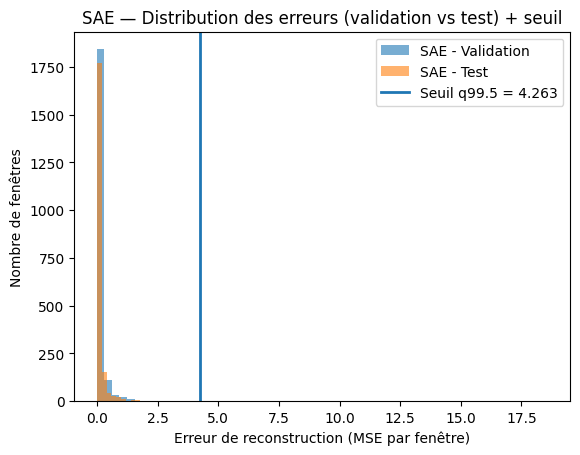

In [28]:
plt.figure()
plt.hist(val_err_sae, bins=60, alpha=0.6, label="SAE - Validation")
plt.hist(test_err_sae, bins=60, alpha=0.6, label="SAE - Test")
plt.axvline(threshold_sae, linewidth=2, label=f"Seuil q99.5 = {threshold_sae:.3f}")
plt.xlabel("Erreur de reconstruction (MSE par fenêtre)")
plt.ylabel("Nombre de fenêtres")
plt.title("SAE — Distribution des erreurs (validation vs test) + seuil")
plt.legend()
plt.show()


### 9.10 Série temporelle / index + anomalies

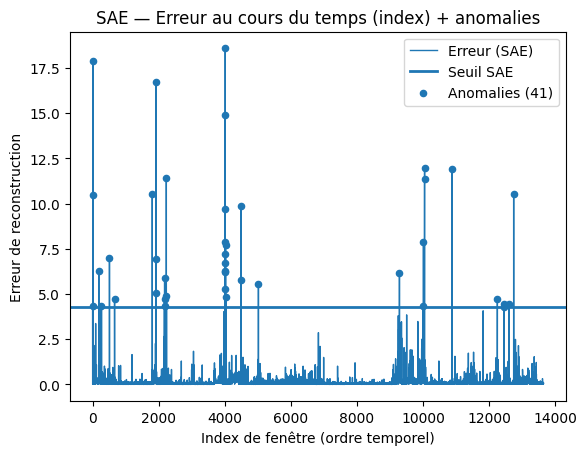

Nb anomalies SAE: 41


In [29]:
all_err_sae = reconstruction_errors_array(model_sae, X_all_s)
df_vis_sae = make_df_vis(df, all_err_sae, threshold_sae)

anom_sae = df_vis_sae[df_vis_sae["is_anomaly"] == 1]

plt.figure()
plt.plot(df_vis_sae["win_idx"], df_vis_sae["recon_error"], linewidth=1, label="Erreur (SAE)")
plt.axhline(threshold_sae, linewidth=2, label="Seuil SAE")
if len(anom_sae) > 0:
    plt.scatter(anom_sae["win_idx"], anom_sae["recon_error"], s=20, label=f"Anomalies ({len(anom_sae)})")

plt.xlabel("Index de fenêtre (ordre temporel)")
plt.ylabel("Erreur de reconstruction")
plt.title("SAE — Erreur au cours du temps (index) + anomalies")
plt.legend()
plt.show()

print("Nb anomalies SAE:", len(anom_sae))


### 9.11 Boxplots

/tmp/ipykernel_27695/2542313639.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([val_err_sae, test_err_sae], labels=["SAE Val", "SAE Test"], showfliers=False)


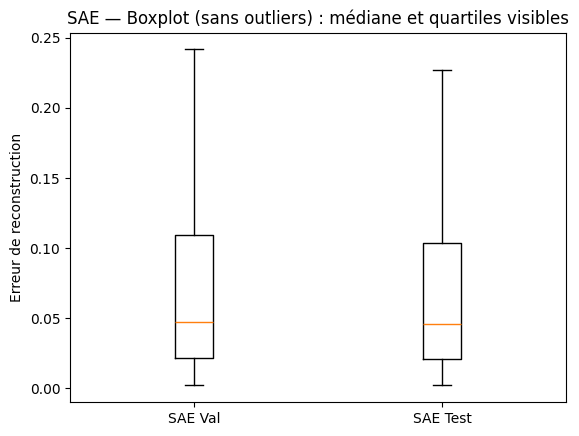

/tmp/ipykernel_27695/2542313639.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([val_err_sae + 1e-9, test_err_sae + 1e-9], labels=["SAE Val", "SAE Test"], showfliers=True)


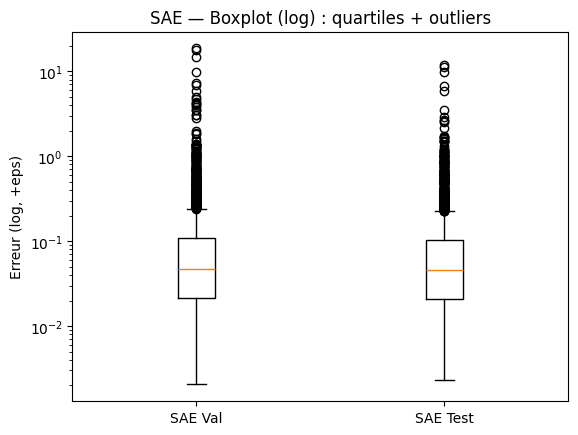

In [30]:
plt.figure()
plt.boxplot([val_err_sae, test_err_sae], labels=["SAE Val", "SAE Test"], showfliers=False)
plt.ylabel("Erreur de reconstruction")
plt.title("SAE — Boxplot (sans outliers) : médiane et quartiles visibles")
plt.show()

# Option log (pour voir les extrêmes)
plt.figure()
plt.boxplot([val_err_sae + 1e-9, test_err_sae + 1e-9], labels=["SAE Val", "SAE Test"], showfliers=True)
plt.yscale("log")
plt.ylabel("Erreur (log, +eps)")
plt.title("SAE — Boxplot (log) : quartiles + outliers")
plt.show()


### 9.12 Taux d'anomalies agrégé par heure

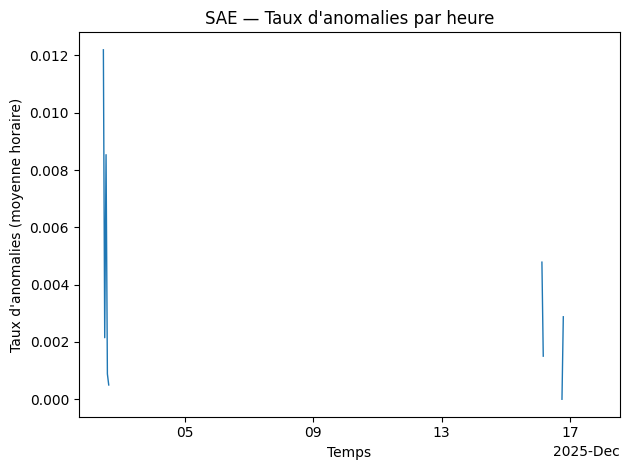

In [31]:
df_rate = df_vis_sae.dropna(subset=["window_start"]).copy().set_index("window_start")
rate_h = df_rate["is_anomaly"].resample("1h").mean()

plt.figure()
plt.plot(rate_h.index, rate_h.values, linewidth=1)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4, maxticks=8))
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

plt.xlabel("Temps")
plt.ylabel("Taux d'anomalies (moyenne horaire)")
plt.title("SAE — Taux d'anomalies par heure")
plt.tight_layout()
plt.show()


## Superpositions AE vs DAE vs SAE (les 2 plus importants)

### Histogramme TEST superposé + seuils

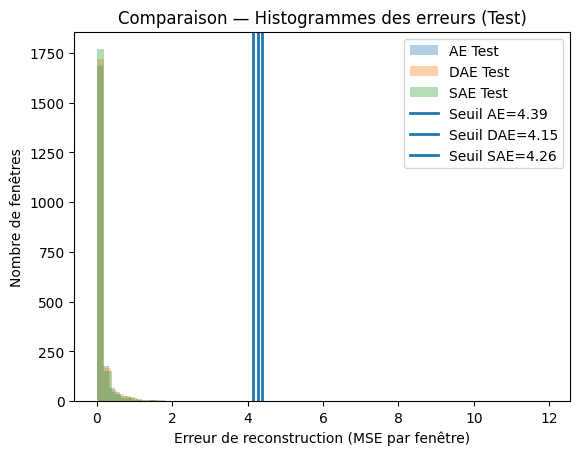

In [32]:
plt.figure()
plt.hist(test_err_ae,  bins=60, alpha=0.35, label="AE Test")
plt.hist(test_err_dae, bins=60, alpha=0.35, label="DAE Test")
plt.hist(test_err_sae, bins=60, alpha=0.35, label="SAE Test")

plt.axvline(threshold_ae,  linewidth=2, label=f"Seuil AE={threshold_ae:.2f}")
plt.axvline(threshold_dae, linewidth=2, label=f"Seuil DAE={threshold_dae:.2f}")
plt.axvline(threshold_sae, linewidth=2, label=f"Seuil SAE={threshold_sae:.2f}")

plt.xlabel("Erreur de reconstruction (MSE par fenêtre)")
plt.ylabel("Nombre de fenêtres")
plt.title("Comparaison — Histogrammes des erreurs (Test)")
plt.legend()
plt.show()


### Courbes index superposées (erreurs sur tout le dataset)

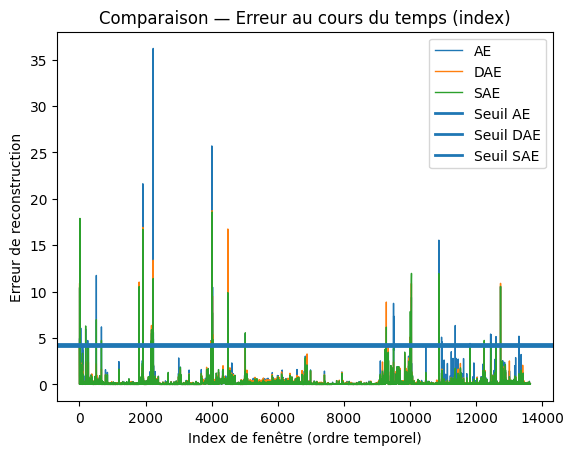

In [33]:
plt.figure()
plt.plot(df_vis_ae["win_idx"],  df_vis_ae["recon_error"],  linewidth=1, label="AE")
plt.plot(df_vis_dae["win_idx"], df_vis_dae["recon_error"], linewidth=1, label="DAE")
plt.plot(df_vis_sae["win_idx"], df_vis_sae["recon_error"], linewidth=1, label="SAE")

plt.axhline(threshold_ae,  linewidth=2, label="Seuil AE")
plt.axhline(threshold_dae, linewidth=2, label="Seuil DAE")
plt.axhline(threshold_sae, linewidth=2, label="Seuil SAE")

plt.xlabel("Index de fenêtre (ordre temporel)")
plt.ylabel("Erreur de reconstruction")
plt.title("Comparaison — Erreur au cours du temps (index)")
plt.legend()
plt.show()


# Tableau de synthèse

In [34]:
import pandas as pd

summary = pd.DataFrame([
    {"Model": "AE",  "threshold_q99.5": float(threshold_ae),
     "val_mean": float(val_err_ae.mean()),  "val_std": float(val_err_ae.std()),
     "test_mean": float(test_err_ae.mean()), "test_std": float(test_err_ae.std()),
     "test_anom_rate": float((test_err_ae > threshold_ae).mean())
    },
    {"Model": "DAE", "threshold_q99.5": float(threshold_dae),
     "val_mean": float(val_err_dae.mean()), "val_std": float(val_err_dae.std()),
     "test_mean": float(test_err_dae.mean()), "test_std": float(test_err_dae.std()),
     "test_anom_rate": float((test_err_dae > threshold_dae).mean())
    },
    {"Model": "SAE", "threshold_q99.5": float(threshold_sae),
     "val_mean": float(val_err_sae.mean()), "val_std": float(val_err_sae.std()),
     "test_mean": float(test_err_sae.mean()), "test_std": float(test_err_sae.std()),
     "test_anom_rate": float((test_err_sae > threshold_sae).mean())
    },
])

summary


,Model,threshold_q99.5,val_mean,val_std,test_mean,test_std,test_anom_rate
0,AE,4.389127,0.198679,0.914067,0.147874,0.493612,0.002931
1,DAE,4.146696,0.183785,0.805798,0.143368,0.481814,0.002443
2,SAE,4.262525,0.178521,0.813598,0.139139,0.520484,0.002443


## 10) Comparaison & synthèse

On compare les trois modèles (AE, DAE, SAE) sur la distribution des erreurs de reconstruction et un indicateur simple : le taux d'échantillons dont l'erreur dépasse le seuil (seuil calculé sur la validation).

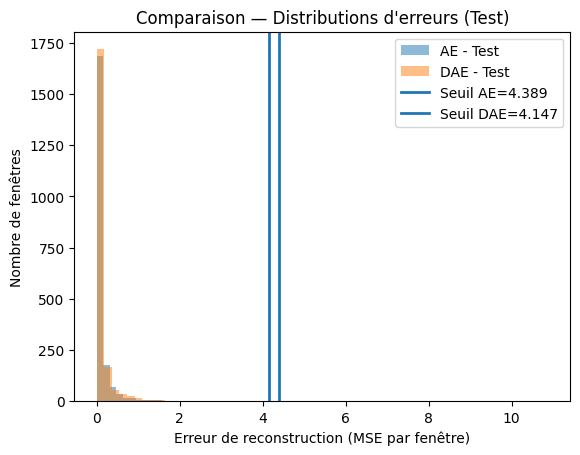

In [35]:
plt.figure()
plt.hist(test_err_ae,  bins=60, alpha=0.5, label="AE - Test")
plt.hist(test_err_dae, bins=60, alpha=0.5, label="DAE - Test")
plt.axvline(threshold_ae,  linewidth=2, label=f"Seuil AE={threshold_ae:.3f}")
plt.axvline(threshold_dae, linewidth=2, label=f"Seuil DAE={threshold_dae:.3f}")
plt.xlabel("Erreur de reconstruction (MSE par fenêtre)")
plt.ylabel("Nombre de fenêtres")
plt.title("Comparaison — Distributions d'erreurs (Test)")
plt.legend()
plt.show()


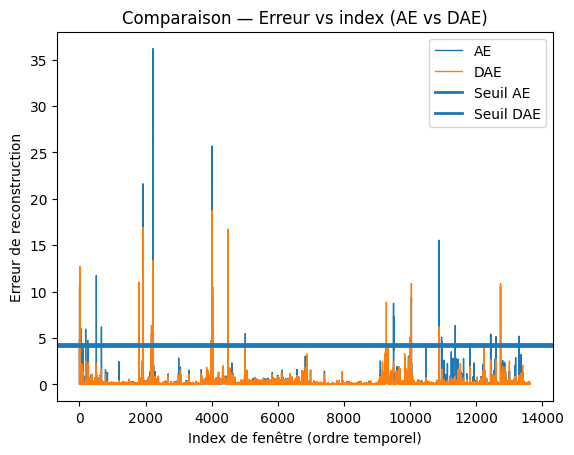

In [36]:
plt.figure()
plt.plot(df_vis_ae["win_idx"],  df_vis_ae["recon_error"],  linewidth=1, label="AE")
plt.plot(df_vis_dae["win_idx"], df_vis_dae["recon_error"], linewidth=1, label="DAE")
plt.axhline(threshold_ae,  linewidth=2, label="Seuil AE")
plt.axhline(threshold_dae, linewidth=2, label="Seuil DAE")
plt.xlabel("Index de fenêtre (ordre temporel)")
plt.ylabel("Erreur de reconstruction")
plt.title("Comparaison — Erreur vs index (AE vs DAE)")
plt.legend()
plt.show()


## Notes de reproductibilité

- Le scaler est ajusté **uniquement** sur le train puis appliqué à val/test (évite la fuite de données).
- Les seuils d'anomalie sont calculés sur **la validation** (`THRESH_Q`), puis reportés sur le test.
- Les artefacts (poids, scaler, métadonnées) sont exportés dans `artifacts_*` pour intégration dans la suite du mémoire.
